# Does Gender Play a Role in the Importance of Religious Identity in 16-Year-Olds in Northern Ireland?
## Data Analytics Case Study Code File
### Author: Mattia Buonaiuto, Olubunmi Ojo, Sweata Seethapathi


### Group: D.5





In [1]:
# Import modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency, pearsonr

In [2]:
import sys
!{sys.executable} -m pip install pyreadstat

  Using cached pyreadstat-1.3.6-cp313-cp313-win_amd64.whl.metadata (1.3 kB)
Using cached pyreadstat-1.3.6-cp313-cp313-win_amd64.whl (2.0 MB)

  Attempting uninstall: narwhals

    Found existing installation: narwhals 2.7.0

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
    Uninstalling narwhals-2.7.0:
   ---------------------------------------- 0/2 [narwhals]
      Successfully uninstalled narwhals-2.7.0
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2

### Research Question(RQ): Does Gender Play A Role In The Importance Of Religious Identity in 16-Year-Olds In Northern Ireland?

#### Our focus is mainly on columns that have to do with **Gender**, **Religious Identity**, and **Importance of Religious Identity**. 

##### Now, we will be comparing and analysing the gender column (rsex) with every other column or variable that has to do with religious identity and its importance. 

##### Then, we will confirm it using statistical analysis such as p-test and chi-square test. 


In [4]:
#Import stata data file containing all relevant data.

df = pd.read_stata(r"C:\Users\BunmiOjo\Downloads\YLT (1).dta")

#### Preview The Dataset

In [21]:
df.shape

(9168, 25)

In [99]:
df.head(10)

,respondentID,year,rsex,yearsni,placeliv,thisoct,oct2yrs,typeschl,relschl,welloff,...,ninatid,natidimp,protcath,rlrelago,rlrelfut,relgalwy,mxrlgngh,mxrlgwrk,ownmxsch,ownreligion
0,1,2012,Male,16,A small city or town,At school or college full time,"At college or university, and working part time",Grammar,All or nearly all Catholic,Average,...,Irish,Very important,Part of the Catholic community,About the same,About the same,Yes,Own religion,Mixed religion,Own religion,2
1,2,2012,Male,16,A country village,At school or college full time,Working full time,Secondary,All or nearly Protestant,Not very well off,...,British,Quite important,Part of the Protestant community,About the same,About the same,No,Own religion,Mixed religion,Own religion,2
2,3,2012,Female,16,A small city or town,At school or college full time,Going to college or university full time,Secondary,Mostly Protestant,Not very well off,...,Northern Irish,Not very important,Part of the Protestant community,Better,Better,Yes,Mixed religion,Mixed religion,Mixed religion,0
3,4,2012,Male,16,A farm or home in the country,At school or college full time,Going to college or university full time,Grammar,Mostly Protestant,Not very well off,...,British,Not very important,Neither,Don't know,Better,Don't know,Mixed religion,Mixed religion,Mixed religion,0
4,5,2012,Male,16,A small city or town,At school or college full time,Working full time,Secondary,Mostly Protestant,Not very well off,...,Irish,Quite important,Part of the Catholic community,Worse,About the same,Yes,Own religion,Mixed religion,Other,1
5,6,2012,Female,14,A small city or town,At school or college full time,Going to college or university full time,Secondary,All or nearly all Catholic,Average,...,Irish,Neither important nor unimportant,Part of the Catholic community,Better,Better,Yes,Mixed religion,Mixed religion,Own religion,1
6,7,2012,Female,16,The suburbs or outskirts of a big city,At school or college full time,Going to college or university full time,Grammar,Mostly Protestant,Well off,...,British,Quite important,Part of the Protestant community,About the same,Worse,Yes,Don't know,Don't know,Don't know,0
7,8,2012,Female,16,A country village,"At school or college, and working part time",Going to college or university full time,Grammar,All or nearly all Catholic,Average,...,Irish,Quite important,Part of the Catholic community,Better,Better,No,Don't know,Mixed religion,Own religion,1
8,9,2012,Female,16,The suburbs or outskirts of a big city,At school or college full time,"At college or university, and working part time",Grammar,All or nearly all Catholic,Average,...,Northern Irish,Not at all important,Part of the Catholic community,Better,Better,Yes,Mixed religion,Mixed religion,Mixed religion,0
9,10,2012,Male,16,A farm or home in the country,"At school or college, and working part time","At college or university, and working part time",Other,About half Protestant and half Catholic,Average,...,British,Very important,Part of the Protestant community,Better,About the same,Yes,Mixed religion,Mixed religion,Own religion,1


In [24]:
df.columns

Index(['respondentID', 'year', 'rsex', 'yearsni', 'placeliv', 'thisoct',
       'oct2yrs', 'typeschl', 'relschl', 'welloff', 'sexatt', 'relarea',
       'anyrelig', 'religion', 'relidimp', 'ninatid', 'natidimp', 'protcath',
       'rlrelago', 'rlrelfut', 'relgalwy', 'mxrlgngh', 'mxrlgwrk', 'ownmxsch',
       'ownreligion'],
      dtype='object')

In [25]:
df.isnull().sum()

respondentID    0
year            0
rsex            0
yearsni         0
placeliv        0
thisoct         0
oct2yrs         0
typeschl        0
relschl         0
welloff         0
sexatt          0
relarea         0
anyrelig        0
religion        0
relidimp        0
ninatid         0
natidimp        0
protcath        0
rlrelago        0
rlrelfut        0
relgalwy        0
mxrlgngh        0
mxrlgwrk        0
ownmxsch        0
ownreligion     0
dtype: int64

In [26]:
df.describe()

,respondentID,year
count,9168.000000,9168.000000
mean,4584.500000,2007.907177
std,2646.717968,3.008733
min,1.000000,2003.000000
25%,2292.750000,2005.000000
50%,4584.500000,2008.000000
75%,6876.250000,2011.000000
max,9168.000000,2012.000000


#### Comparison And Analysis Begins

In [29]:
df["rsex"].value_counts()

rsex
Female     5373
Male       3753
Missing      42
Name: count, dtype: int64

##### There were more females than males in the survey.

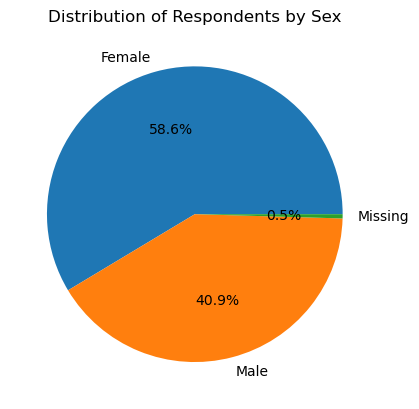

In [47]:
df["rsex"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Distribution of Respondents by Sex")
plt.ylabel("")
plt.show()

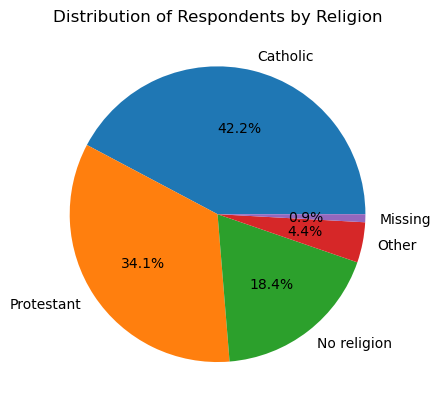

In [100]:
# Distribution of Respondents by Religion

df["religion"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Distribution of Respondents by Religion")
plt.ylabel("")
plt.show()

In [101]:
# Count Of Respondents By National Identity

df["ninatid"].value_counts()

ninatid
Irish             3357
Northern Irish    2596
British           2358
Ulster             315
Other              273
Missing            167
Don't know         102
Name: count, dtype: int64

In [ ]:
df.groupby("rsex")["ninatid"].value_counts()

C:\Users\BunmiOjo\AppData\Local\Temp\ipykernel_33356\2628475438.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("rsex")["ninatid"].value_counts()


rsex     ninatid       
Male     Irish             1368
         Northern Irish    1036
         British            957
         Ulster             169
         Other              120
         Missing             65
         Don't know          38
Female   Irish             1972
         Northern Irish    1549
         British           1398
         Other              152
         Ulster             146
         Missing             93
         Don't know          63
Missing  Irish               17
         Northern Irish      11
         Missing              9
         British              3
         Other                1
         Don't know           1
         Ulster               0
Name: count, dtype: int64

##### There were more female Northern Irish 16-year olds than there were males.

# Hypothesis Framework


Does Gender Play A Role In The Importance Of Religious Identity in 16-Year-Olds In Northern Ireland?

H₀ (Null Hypothesis):
There is no significant difference in the importance of religious identity and the gender of 16-year-olds in Northern Ireland.


H₁ (Alternative Hypothesis):
There is a significant difference in the importance of religious identity and the gender of 16-year-olds in Northern Ireland.  


#### Checking If Gender (rsex) Is Related To The Respondents' Particular Religion (religion).

In [144]:
table = pd.crosstab(df["rsex"], df["religion"], normalize ="index") * 100
table

religion,Protestant,Catholic,No religion,Other,Missing
rsex,,,,,
Male,33.759659,39.621636,21.556088,4.103384,0.959233
Female,34.338358,44.053601,16.285129,4.615671,0.707240
Missing,23.809524,45.238095,11.904762,4.761905,14.285714


##### More 16 year olds had a particular religion. There were more females with a religion than the males. 

In [143]:
# For two categorical variables, chi-square test is more appropriate.

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")

Chi-square statistic: 28.260
P-value: 0.00043


#####  A large chi-square statistic of 28.260 indicates that observed results differ more from what we would expect, suggesting a possible relationship.
#####  p < 0.05: Evidence suggests a meaningful difference. Therefore rsex and religion are related. 

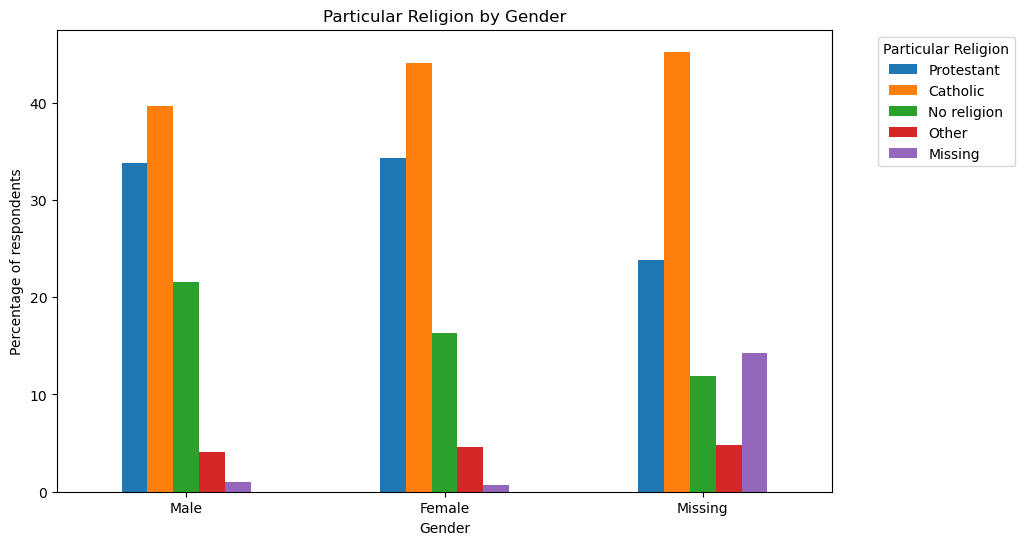

In [142]:
# Plot grouped percentage bar chart

percentage_table = pd.crosstab(df["rsex"], df["religion"], normalize="index") * 100
percentage_table.plot(kind="bar", figsize=(10,6))

plt.xlabel("Gender")
plt.ylabel("Percentage of respondents")
plt.title("Particular Religion by Gender")
plt.xticks(rotation=0)
plt.legend(title="Particular Religion", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout
plt.show()

#### Checking If Gender (rsex) Is Related To The Respondents' Opinion On Importance of Religious Identity (relidimp).

In [141]:
table_1 = pd.crosstab(df["rsex"], df["relidimp"], normalize ="index") * 100
table_1

relidimp,Very important,Quite important,Neither important nor unimportant,Not very important,Not at all important,I don't have a religious identity,Don't know,Missing,Not asked
rsex,,,,,,,,,
Male,21.742606,23.741007,17.106315,10.444977,11.457501,6.608047,0.239808,1.039169,7.620570
Female,19.076866,26.093430,19.151312,10.478318,11.427508,3.778150,0.186116,0.521124,9.287177
Missing,19.047619,21.428571,21.428571,4.761905,11.904762,0.000000,0.000000,19.047619,2.380952


##### More females identify religion as very or quite important than the males.

In [140]:
chi2, p, dof, expected = chi2_contingency(table_1)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")

Chi-square statistic: 46.744
P-value: 0.00007


##### A large chi-square statistic of 46.744 indicates that observed results differ more from what we would expect, suggesting a possible relationship.
##### p < 0.05: Evidence suggests a meaningful difference. Therefore, rsex and relidimp are related. 

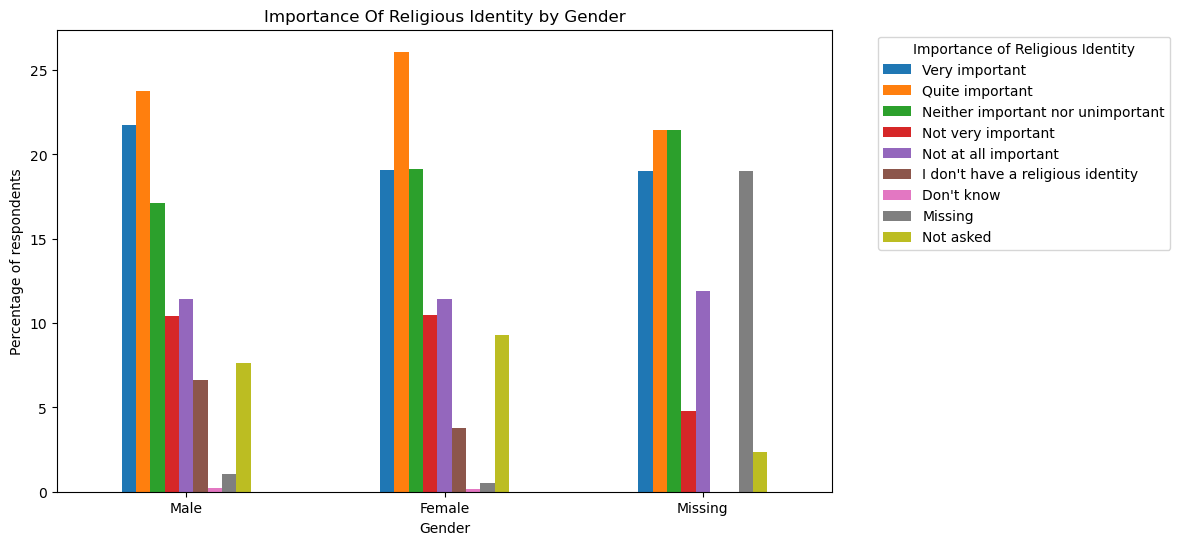

In [ ]:
# Plot grouped percentage bar chart

percentage_table = pd.crosstab(df["rsex"], df["relidimp"], normalize="index") * 100
percentage_table.plot(kind="bar", figsize=(10,6))

plt.xlabel("Gender")
plt.ylabel("Percentage of respondents")
plt.title("Importance Of Religious Identity by Gender")
plt.xticks(rotation=0)
plt.legend(title="Importance of Religious Identity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout
plt.show()

#### Checking If Gender (rsex) Is Related To The Respondents' Opinion Of Religious Influence (relgalwy).

In [112]:
table_2 = pd.crosstab(df["rsex"], df["relgalwy"], normalize ="index") * 100
table_2

relgalwy,Yes,No,Other,Don't know,Missing
rsex,,,,,
Male,78.603784,12.976286,3.730349,3.783640,0.905942
Female,81.648986,9.864135,4.131770,3.312861,1.042248
Missing,66.666667,9.523810,0.000000,0.000000,23.809524


##### More 16-year old females agreed that religion will always influence how people feel about each other in Northern Ireland.

In [114]:
chi2, p, dof, expected = chi2_contingency(table_2)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")

Chi-square statistic: 50.377
P-value: 0.00000


#####  A large chi-square statistic of 50.377 indicates that observed results differ more from what we would expect, suggesting a possible relationship.
##### p < 0.05: Evidence suggests a meaningful difference. Therefore rsex and relgalwy are related. 

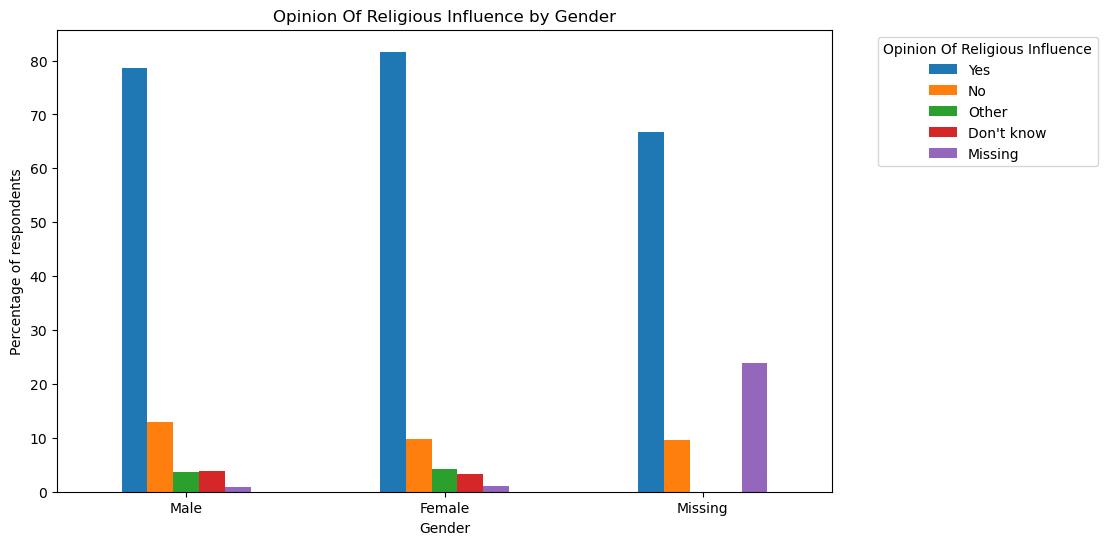

In [138]:
# Plot grouped percentage bar chart

percentage_table = pd.crosstab(df["rsex"], df["relgalwy"], normalize="index") * 100
percentage_table.plot(kind="bar", figsize=(10,6))

plt.xlabel("Gender")
plt.ylabel("Percentage of respondents")
plt.title("Opinion Of Religious Influence by Gender")
plt.xticks(rotation=0)
plt.legend(title="Opinion Of Religious Influence", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout
plt.show()

#### Checking If Gender (rsex) Is Related To The Respondents' as Members Of A Religious Community (protcath).

In [116]:
table_3 = pd.crosstab(df["rsex"], df["protcath"], normalize ="index") * 100
table_3

protcath,Part of the Protestant community,Part of the Catholic community,Neither,Missing
rsex,,,,
Male,38.689049,39.621636,19.877431,1.811884
Female,39.605435,42.155221,16.136237,2.103108
Missing,23.809524,42.857143,11.904762,21.428571


In [118]:
chi2, p, dof, expected = chi2_contingency(table_3)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")

Chi-square statistic: 36.676
P-value: 0.00000


#####  A large chi-square statistic of 36.676 indicates that observed results differ more from what we would expect, suggesting a possible relationship.
##### p < 0.05: Evidence suggests a meaningful difference. Therefore rsex and protcath are related. 

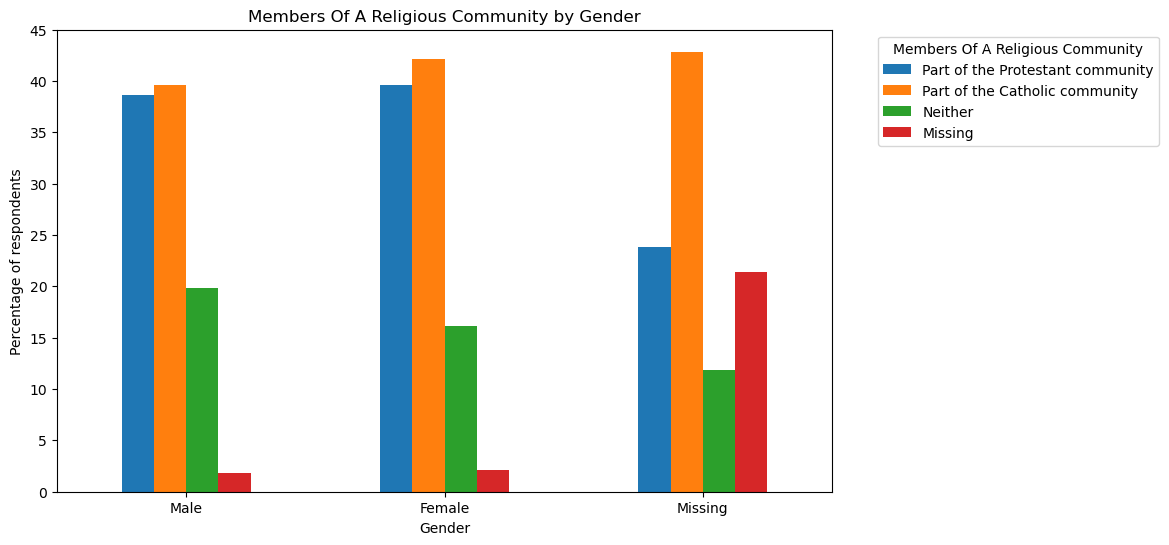

In [137]:
# Plot grouped percentage bar chart

percentage_table = pd.crosstab(df["rsex"], df["protcath"], normalize="index") * 100
percentage_table.plot(kind="bar", figsize=(10,6))

plt.xlabel("Gender")
plt.ylabel("Percentage of respondents")
plt.title("Members Of A Religious Community by Gender")
plt.xticks(rotation=0)
plt.legend(title="Members Of A Religious Community", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout
plt.show()

#### Checking If Gender (rsex) Is Related To The Respondents' Preference For Own Religion (ownreligion).

In [120]:
table_4 = pd.crosstab(df["rsex"], df["ownreligion"], normalize ="index") * 100
table_4

ownreligion,0,1,2,3,Missing
rsex,,,,,
Male,47.881695,21.715961,15.747402,12.390088,2.264855
Female,54.383026,23.525033,13.009492,6.904895,2.177554
Missing,42.857143,14.285714,14.285714,7.142857,21.428571


#### Neither males nor females preferred their own religion as their most favoured overall.

In [121]:
chi2, p, dof, expected = chi2_contingency(table_4)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")

Chi-square statistic: 34.761
P-value: 0.00003


#####  A large chi-square statistic of 34.761 indicates that observed results differ more from what we would expect, suggesting a possible relationship.
##### p < 0.05: Evidence suggests a meaningful difference. Therefore rsex and ownreligion are related. 

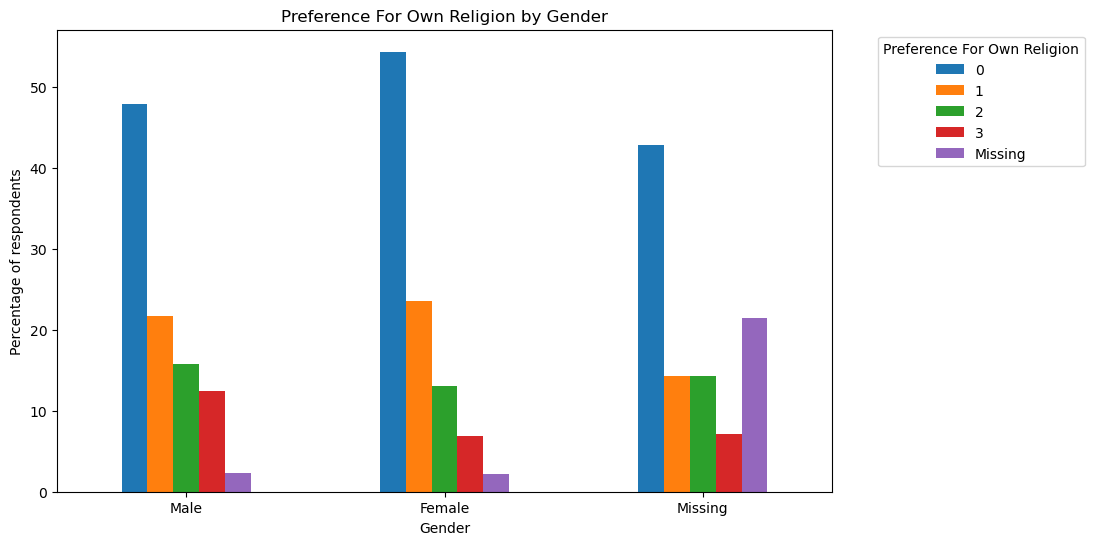

In [136]:
# Plot grouped percentage bar chart

percentage_table = pd.crosstab(df["rsex"], df["ownreligion"], normalize="index") * 100
percentage_table.plot(kind="bar", figsize=(10,6))

plt.xlabel("Gender")
plt.ylabel("Percentage of respondents")
plt.title("Preference For Own Religion by Gender")
plt.xticks(rotation=0)
plt.legend(title="Preference For Own Religion", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout
plt.show()

#### Checking If Gender (rsex) Is Related To The Respondents' Religious Preference For Neighborhood (mxrlgngh).

In [123]:
table_5 = pd.crosstab(df["rsex"], df["mxrlgngh"], normalize ="index") * 100
table_5

mxrlgngh,Own religion,Mixed religion,Other,Don't know,Missing
rsex,,,,,
Male,32.160938,52.118305,6.261657,8.713030,0.746070
Female,23.487809,61.139028,5.992928,8.375209,1.005025
Missing,23.809524,45.238095,9.523810,2.380952,19.047619


##### Most of the 16-year olds preferred to live in a neighbourhood with people of mixed religion. There were more females than males that preferred this option. 

In [124]:
chi2, p, dof, expected = chi2_contingency(table_5)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")

Chi-square statistic: 40.967
P-value: 0.00000


##### A large chi-square statistic of 40.967 indicates that observed results differ more from what we would expect, suggesting a possible relationship.
##### p < 0.05: Evidence suggests a meaningful difference. Therefore rsex and mxrlgngh are related. 

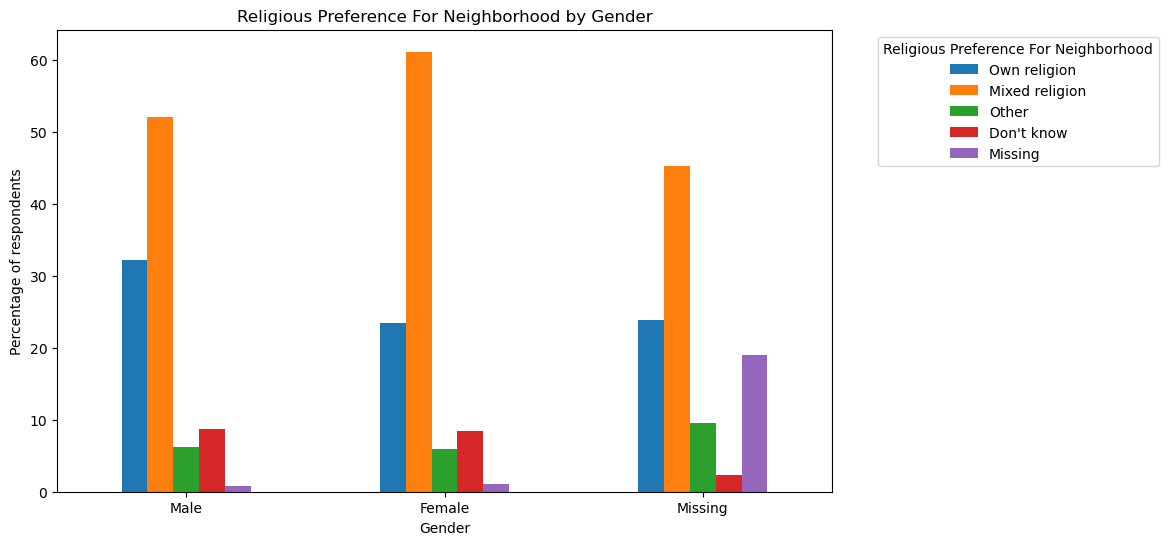

In [135]:
# Plot grouped percentage bar chart

percentage_table = pd.crosstab(df["rsex"], df["mxrlgngh"], normalize="index") * 100
percentage_table.plot(kind="bar", figsize=(10,6))

plt.xlabel("Gender")
plt.ylabel("Percentage of respondents")
plt.title("Religious Preference For Neighborhood by Gender")
plt.xticks(rotation=0)
plt.legend(title="Religious Preference For Neighborhood", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout
plt.show()

#### Checking If Gender (rsex) Is Related To The Respondents' Religious Preference For Workplace (mxrlgwrk).

In [126]:
table_6 = pd.crosstab(df["rsex"], df["mxrlgwrk"], normalize ="index") * 100
table_6

mxrlgwrk,Own religion,Mixed religion,Other,Don't know,Missing
rsex,,,,,
Male,15.907274,67.013056,7.887024,8.233413,0.959233
Female,9.808301,75.674670,6.849060,6.495440,1.172529
Missing,7.142857,64.285714,7.142857,2.380952,19.047619


##### Way more 16-year olds preferred a workplace with people of mixed religion. There were more females than males that preferred this option. 

In [127]:
chi2, p, dof, expected = chi2_contingency(table_6)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")

Chi-square statistic: 38.494
P-value: 0.00001


#####  A large chi-square statistic of 38.494 indicates that observed results differ more from what we would expect, suggesting a possible relationship.
##### p < 0.05: Evidence suggests a meaningful difference. Therefore rsex and mxrlgwrk are related. 

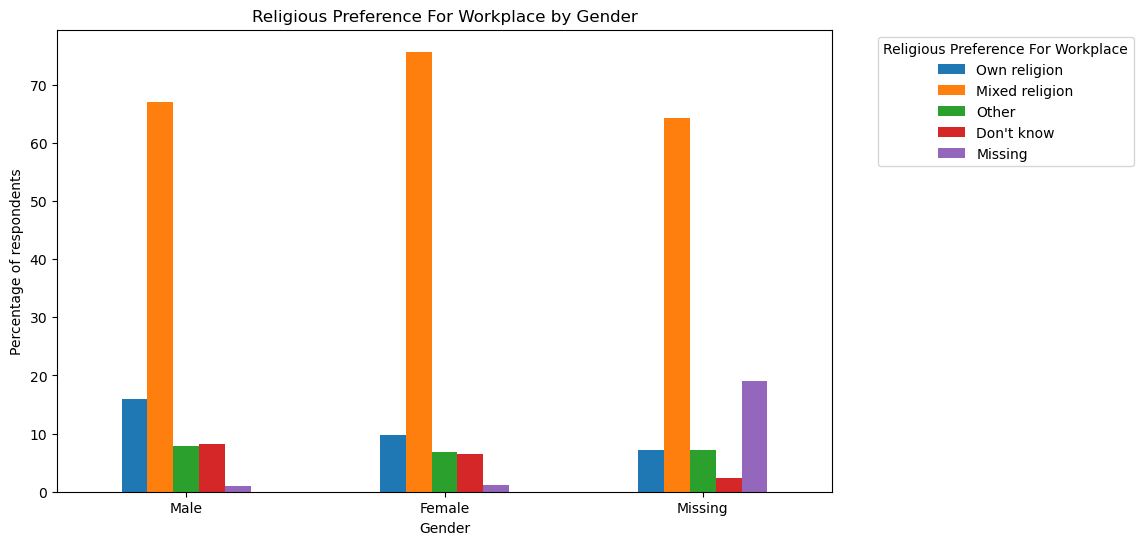

In [ ]:
# Plot grouped percentage bar chart

percentage_table = pd.crosstab(df["rsex"], df["mxrlgwrk"], normalize="index") * 100
percentage_table.plot(kind="bar", figsize=(10,6))

plt.xlabel("Gender")
plt.ylabel("Percentage of respondents")
plt.title("Religious Preference For Workplace by Gender")
plt.xticks(rotation=0)
plt.legend(title="Religious Preference For Workplace", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout
plt.show()

#### Checking If Gender (rsex) Is Related To The Respondents' Religious Preference For School (ownmxsch).

In [129]:
table_7 = pd.crosstab(df["rsex"], df["ownmxsch"], normalize ="index") * 100
table_7

ownmxsch,Own religion,Mixed religion,Other,Don't know,Missing
rsex,,,,,
Male,43.138822,42.925659,5.222489,7.007727,1.705302
Female,37.818723,48.911223,4.113158,7.295738,1.861158
Missing,33.333333,33.333333,7.142857,4.761905,21.428571


##### The males preferred a school with children of their own religion while a higher number of females preferred a school with children of mixed religion.

In [130]:
chi2, p, dof, expected = chi2_contingency(table_7)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")

Chi-square statistic: 36.569
P-value: 0.00001


#####  A large chi-square statistic of 36.569 indicates that observed results differ more from what we would expect, suggesting a possible relationship.
##### p < 0.05: Evidence suggests a meaningful difference. Therefore rsex and ownmxsch are related.

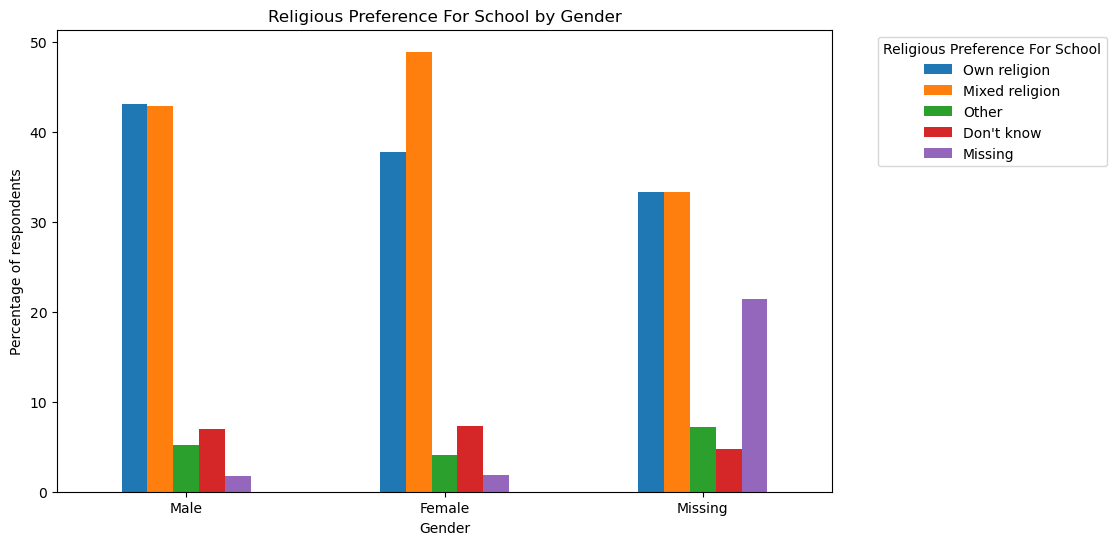

In [ ]:
# Plot grouped percentage bar chart

percentage_table = pd.crosstab(df["rsex"], df["ownmxsch"], normalize = "index") * 100
percentage_table.plot(kind="bar", figsize=(10,6))

plt.xlabel("Gender")
plt.ylabel("Percentage of respondents")
plt.title("Religious Preference For School by Gender")
plt.xticks(rotation=0)
plt.legend(title="Religious Preference For School", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout
plt.show()

#### Checking If Gender (rsex) Is Related To The Respondents' Belonging To A Particular Religion (anyrelig).

In [132]:
table_8 = pd.crosstab(df["rsex"], df["anyrelig"], normalize ="index") * 100
table_8

anyrelig,Yes,No,Missing
rsex,,,
Male,77.911005,21.129763,0.959233
Female,83.286804,16.080402,0.632794
Missing,73.809524,7.142857,19.047619


##### More females identified with a particular religion than the males.

In [133]:
chi2, p, dof, expected = chi2_contingency(table_8)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")

Chi-square statistic: 39.651
P-value: 0.00000


#####  A large chi-square statistic of 39.651 indicates that observed results differ more from what we would expect, suggesting a possible relationship.
##### p < 0.05: Evidence suggests a meaningful difference. Therefore rsex and anyrelig are related.

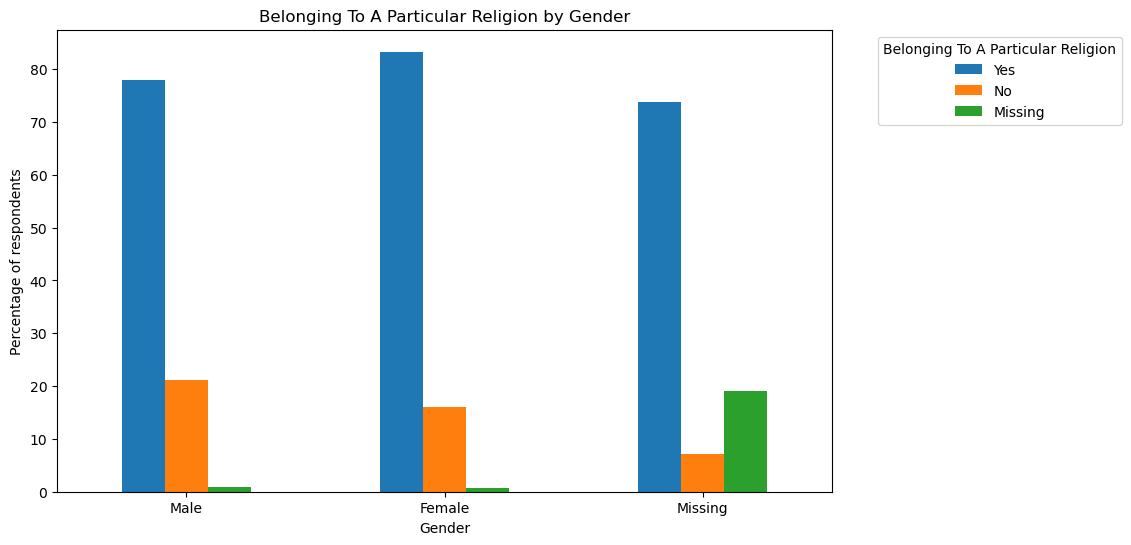

In [134]:
# Plot grouped percentage bar chart

percentage_table = pd.crosstab(df["rsex"], df["anyrelig"], normalize = "index") * 100
percentage_table.plot(kind="bar", figsize=(10,6))

plt.xlabel("Gender")
plt.ylabel("Percentage of respondents")
plt.title("Belonging To A Particular Religion by Gender")
plt.xticks(rotation=0)
plt.legend(title="Belonging To A Particular Religion", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout
plt.show()

#### Checking If Gender (rsex) Is Related To The Respondents' Religious Makeup Of School (relschl).

In [6]:
table_9 = pd.crosstab(df["rsex"], df["relschl"], normalize ="index") * 100
table_9

relschl,All or nearly Protestant,All or nearly all Catholic,Mostly Protestant,Mostly Catholic,About half Protestant and half Catholic,Don't know,Missing
rsex,,,,,,,
Male,25.206501,35.917932,15.907274,5.089262,12.629896,3.890221,1.358913
Female,24.064768,37.837335,15.689559,5.062349,13.195608,3.554811,0.595570
Missing,9.523810,19.047619,2.380952,2.380952,0.000000,0.000000,66.666667


In [7]:
chi2, p, dof, expected = chi2_contingency(table_9)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")

Chi-square statistic: 168.925
P-value: 0.00000


#####  A large chi-square statistic of 168.925 indicates that observed results differ more from what we would expect, suggesting a possible relationship.
##### p < 0.05: Evidence suggests a meaningful difference. Therefore rsex and relschl are related.

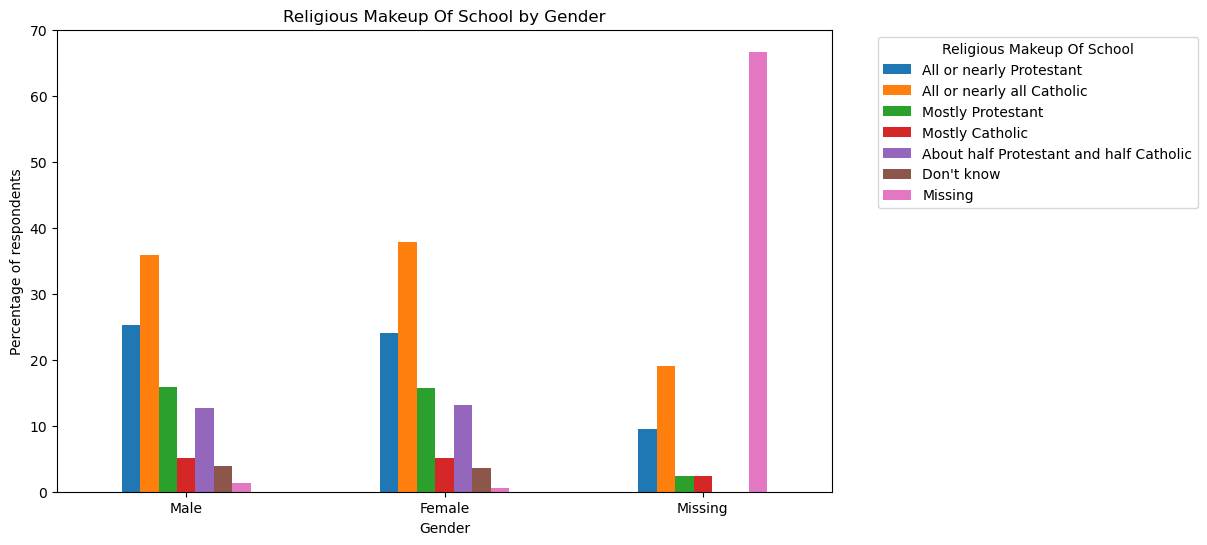

In [147]:
# Plot grouped percentage bar chart

percentage_table = pd.crosstab(df["rsex"], df["relschl"], normalize = "index") * 100
percentage_table.plot(kind="bar", figsize=(10,6))

plt.xlabel("Gender")
plt.ylabel("Percentage of respondents")
plt.title("Religious Makeup Of School by Gender")
plt.xticks(rotation=0)
plt.legend(title="Religious Makeup Of School", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout
plt.show()

 #### Checking If Gender (rsex) Is Related To The Respondents' Religious Makeup Of Area (relarea).

In [148]:
table_10 = pd.crosstab(df["rsex"], df["relarea"], normalize ="index") * 100
table_10

relarea,Mainly Catholic,Mainly Protestant,Mixed,Don't know,Missing
rsex,,,,,
Male,31.574740,35.358380,29.016787,3.437250,0.612843
Female,29.480737,31.974688,33.780011,4.001489,0.763075
Missing,33.333333,28.571429,14.285714,4.761905,19.047619


In [149]:
chi2, p, dof, expected = chi2_contingency(table_10)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")

Chi-square statistic: 42.224
P-value: 0.00000


#####  A large chi-square statistic of 42.224 indicates that observed results differ more from what we would expect, suggesting a possible relationship.
##### p < 0.05: Evidence suggests a meaningful difference. Therefore rsex and relarea are related.

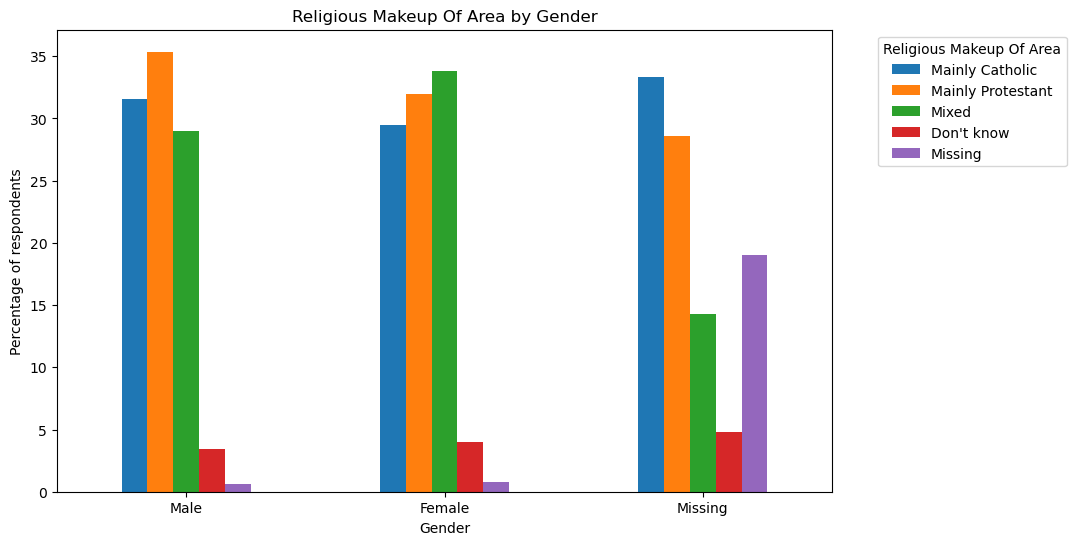

In [150]:
# Plot grouped percentage bar chart

percentage_table = pd.crosstab(df["rsex"], df["relarea"], normalize = "index") * 100
percentage_table.plot(kind="bar", figsize=(10,6))

plt.xlabel("Gender")
plt.ylabel("Percentage of respondents")
plt.title("Religious Makeup Of Area by Gender")
plt.xticks(rotation=0)
plt.legend(title="Religious Makeup Of Area", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout
plt.show()